In [26]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
#Cargamos la base de datos desde un archivo CSV
Bitacora_de_piso= pd.read_csv('Analisis GAC Full7agosto 2026(Bitacora de Piso).csv') 

In [28]:
#Verificamos información del DataFrame
Bitacora_de_piso.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 30 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Fecha                                       198 non-null    str    
 1   Nombre Cliente                              197 non-null    str    
 2   Telefono                                    0 non-null      float64
 3   Asesor                                      196 non-null    str    
 4   Esatus Lead                                 197 non-null    str    
 5   PDM                                         234 non-null    bool   
 6   SDC                                         216 non-null    object 
 7   Estatus de SDC                              2 non-null      str    
 8   Venta                                       216 non-null    object 
 9   Temperatura                                 10 non-null     str    
 10  Inter Gerente            

In [29]:
#Imprimo los primeros 5 registro del dataframe
Bitacora_de_piso.head()

,Fecha,Nombre Cliente,Telefono,Asesor,Esatus Lead,PDM,SDC,Estatus de SDC,Venta,Temperatura,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,04/01/2025,Ubaldo Cruz Hernandez,NaN,Aurelio,Activo,True,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,04/01/2025,Olivia Cabello,NaN,Pedro,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,04/02/2025,Ana Laura Espinoza,NaN,Mauricio,Activo,True,True,Analisis,True,Lead Interes Alto,...,NaN,NaN,NaN,NaN,NaN,NaN,Items,Items,items,items
3,04/02/2025,Elvis Sanchez,NaN,Aurelio,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,Aurelio,Activo,Aprobada,Lead Interes Medio
4,04/03/2025,Ariel Fernando López,NaN,Alan,Activo,True,False,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Pedro,Cerrado,Condicionada,Lead InteresBajo


In [30]:
#Eliminamos los registros que no contienen fecha
Bitacora_de_piso = Bitacora_de_piso.dropna(subset=['Fecha'])

#Reiniciamos los indices
Bitacora_de_piso = Bitacora_de_piso.reset_index(drop=True)

Bitacora_de_piso.info()

<class 'pandas.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 30 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Fecha                                       198 non-null    str    
 1   Nombre Cliente                              197 non-null    str    
 2   Telefono                                    0 non-null      float64
 3   Asesor                                      196 non-null    str    
 4   Esatus Lead                                 197 non-null    str    
 5   PDM                                         198 non-null    bool   
 6   SDC                                         198 non-null    object 
 7   Estatus de SDC                              2 non-null      str    
 8   Venta                                       198 non-null    object 
 9   Temperatura                                 10 non-null     str    
 10  Inter Gerente            

In [31]:
#Eliminamos espacios al inicio y al final de los nombres de las columnas
Bitacora_de_piso.columns = Bitacora_de_piso.columns.str.strip()

#Eliminamos espacios sobrantes en los valores de texto
columnas_texto = Bitacora_de_piso.select_dtypes(include=['object', 'str']).columns

for columna in columnas_texto:
    Bitacora_de_piso[columna] = Bitacora_de_piso[columna].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

#Mostramos los nombres de las columnas
Bitacora_de_piso.columns

Index(['Fecha', 'Nombre Cliente', 'Telefono', 'Asesor', 'Esatus Lead', 'PDM',
       'SDC', 'Estatus de SDC', 'Venta', 'Temperatura', 'Inter Gerente',
       '¿Por que no hubo prueba de manejo?',
       '¿Por que no hubo Solicitud de credito?',
       '¿Por que no hubo intervencion del Gerente?',
       '¿Por que no hubo proceso wow?',
       '¿Por que no se ha formalizado la compra?',
       '5 porques clientes de piso', 'Comentarios', 'Unnamed: 18',
       'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26',
       'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29'],
      dtype='str')

In [33]:
#Eliminamos columnas vacias y columnas auxiliares que no necesitamos
columnas_eliminar = ['Telefono'] + [col for col in Bitacora_de_piso.columns if col.startswith('Unnamed')]

Bitacora_de_piso = Bitacora_de_piso.drop(columns=columnas_eliminar)

#Verificamos nuevamente la información del DataFrame
Bitacora_de_piso.info()

<class 'pandas.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 17 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Fecha                                       198 non-null    str  
 1   Nombre Cliente                              197 non-null    str  
 2   Asesor                                      196 non-null    str  
 3   Esatus Lead                                 197 non-null    str  
 4   PDM                                         198 non-null    bool 
 5   SDC                                         198 non-null    bool 
 6   Estatus de SDC                              2 non-null      str  
 7   Venta                                       198 non-null    bool 
 8   Temperatura                                 10 non-null     str  
 9   Inter Gerente                               198 non-null    bool 
 10  ¿Por que no hubo prueba de manejo?          16 no

In [34]:
#Revisamos las categorias existentes en la variable Asesor
Bitacora_de_piso['Asesor'].value_counts()

Asesor
Aurelio                  34
Mauricio                 28
Pedro                    25
Victor                   20
Alan                     14
Aurelio Torres           13
Pedro González           11
Ricardo                  10
Alan González             9
Mauricio Vazquez          6
Nancy                     3
Ricardo Silva             3
Eduardo                   2
Casa                      2
Alan Gonzalez             2
Marcos Coca               2
Miguel Ramírez            2
Laura                     1
AUrelio                   1
Nancy OLascoaga           1
Pedro Antonio             1
Victor Manuel Sanchez     1
Victor Manuel             1
Pedro Antonio Cinto       1
Victor Sanchez            1
Pedro Gonzalez            1
Mauricio Vázquez          1
Name: count, dtype: int64

In [35]:
#Revisamos las categorias existentes en la variable Esatus Lead
Bitacora_de_piso['Esatus Lead'].value_counts()

Esatus Lead
Activo        168
Cerrado        18
Venta           6
Finalizado      4
venta           1
Name: count, dtype: int64

In [36]:
#Corregimos categorias duplicadas por diferencias de escritura

Bitacora_de_piso['Asesor'] = Bitacora_de_piso['Asesor'].replace({
    'AUrelio': 'Aurelio',
    'Alan Gonzalez': 'Alan González',
    'Pedro Gonzalez': 'Pedro González',
    'Mauricio Vazquez': 'Mauricio Vázquez'
})

Bitacora_de_piso['Esatus Lead'] = Bitacora_de_piso['Esatus Lead'].replace({
    'venta': 'Venta'
})

In [37]:
#Verificamos nuevamente las categorias
print(Bitacora_de_piso['Asesor'].value_counts())

print('\nEstatus Lead:')
print(Bitacora_de_piso['Esatus Lead'].value_counts())

Asesor
Aurelio                  35
Mauricio                 28
Pedro                    25
Victor                   20
Alan                     14
Aurelio Torres           13
Pedro González           12
Alan González            11
Ricardo                  10
Mauricio Vázquez          7
Nancy                     3
Ricardo Silva             3
Eduardo                   2
Casa                      2
Marcos Coca               2
Miguel Ramírez            2
Laura                     1
Nancy OLascoaga           1
Pedro Antonio             1
Victor Manuel Sanchez     1
Victor Manuel             1
Pedro Antonio Cinto       1
Victor Sanchez            1
Name: count, dtype: int64

Estatus Lead:
Esatus Lead
Activo        168
Cerrado        18
Venta           7
Finalizado      4
Name: count, dtype: int64


In [38]:
#VARIABLE CATEGORICA 1: ASESOR

#Creamos una tabla de frecuencias de los asesores
Tabla_Asesor = Bitacora_de_piso['Asesor'].value_counts().reset_index()

#Cambiamos los nombres de las columnas
Tabla_Asesor.columns = ['Asesor', 'Frecuencia']

#Mostramos la tabla
Tabla_Asesor

,Asesor,Frecuencia
0,Aurelio,35
1,Mauricio,28
2,Pedro,25
3,Victor,20
4,Alan,14
5,Aurelio Torres,13
6,Pedro González,12
7,Alan González,11
8,Ricardo,10
9,Mauricio Vázquez,7


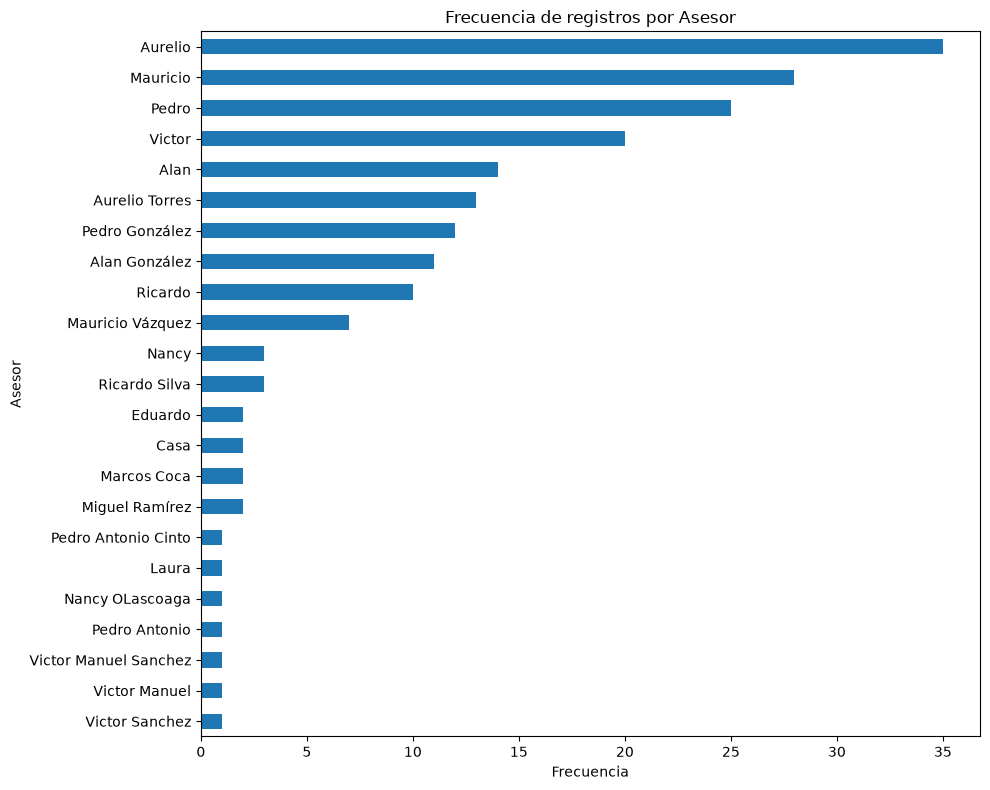

In [39]:
#Graficamos la frecuencia de registros por asesor
Tabla_Asesor_grafica = Tabla_Asesor.sort_values('Frecuencia')

Tabla_Asesor_grafica.plot(
    x='Asesor',
    y='Frecuencia',
    kind='barh',
    figsize=(10, 8),
    legend=False
)

plt.title('Frecuencia de registros por Asesor')
plt.xlabel('Frecuencia')
plt.ylabel('Asesor')
plt.tight_layout()
plt.show()

In [40]:
#Calculamos el porcentaje de registros de cada asesor
Tabla_Asesor['Porcentaje'] = (
    Tabla_Asesor['Frecuencia'] / Tabla_Asesor['Frecuencia'].sum() * 100
).round(2)

Tabla_Asesor

,Asesor,Frecuencia,Porcentaje
0,Aurelio,35,17.86
1,Mauricio,28,14.29
2,Pedro,25,12.76
3,Victor,20,10.20
4,Alan,14,7.14
5,Aurelio Torres,13,6.63
6,Pedro González,12,6.12
7,Alan González,11,5.61
8,Ricardo,10,5.10
9,Mauricio Vázquez,7,3.57


In [41]:
#VARIABLE CATEGORICA 2: ESTATUS LEAD

#Creamos una tabla de frecuencias de los estatus de los leads
Tabla_Estatus = Bitacora_de_piso['Esatus Lead'].value_counts().reset_index()

#Cambiamos los nombres de las columnas
Tabla_Estatus.columns = ['Estatus Lead', 'Frecuencia']

#Calculamos el porcentaje
Tabla_Estatus['Porcentaje'] = (
    Tabla_Estatus['Frecuencia'] / Tabla_Estatus['Frecuencia'].sum() * 100
).round(2)

#Mostramos la tabla
Tabla_Estatus

,Estatus Lead,Frecuencia,Porcentaje
0,Activo,168,85.28
1,Cerrado,18,9.14
2,Venta,7,3.55
3,Finalizado,4,2.03


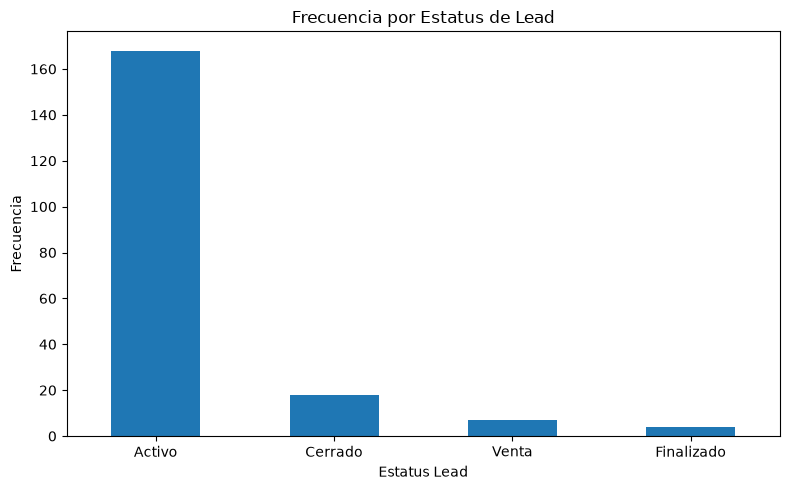

In [42]:
#Graficamos la frecuencia de los estatus de los leads
Tabla_Estatus.plot(
    x='Estatus Lead',
    y='Frecuencia',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Frecuencia por Estatus de Lead')
plt.xlabel('Estatus Lead')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
#VARIABLE CATEGORICA 3: PDM

#Creamos una tabla de frecuencias para PDM
Tabla_PDM = Bitacora_de_piso['PDM'].value_counts().reset_index()

#Cambiamos los nombres de las columnas
Tabla_PDM.columns = ['PDM', 'Frecuencia']

#Calculamos el porcentaje
Tabla_PDM['Porcentaje'] = (
    Tabla_PDM['Frecuencia'] / Tabla_PDM['Frecuencia'].sum() * 100
).round(2)

#Mostramos la tabla
Tabla_PDM

,PDM,Frecuencia,Porcentaje
0,False,123,62.12
1,True,75,37.88


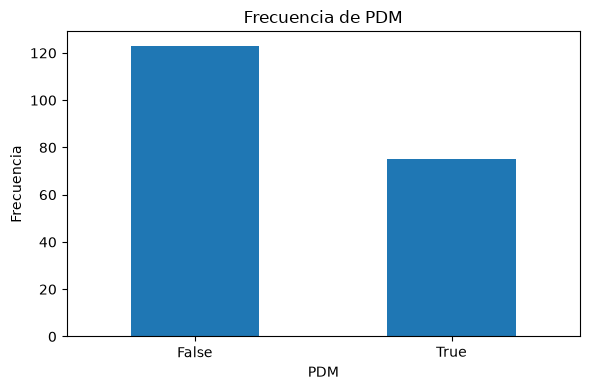

In [44]:
#Graficamos la frecuencia de PDM
Tabla_PDM.plot(
    x='PDM',
    y='Frecuencia',
    kind='bar',
    figsize=(6, 4),
    legend=False
)

plt.title('Frecuencia de PDM')
plt.xlabel('PDM')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [45]:
#VARIABLE CATEGORICA 4: SDC

#Creamos una tabla de frecuencias para SDC
Tabla_SDC = Bitacora_de_piso['SDC'].value_counts().reset_index()

#Cambiamos los nombres de las columnas
Tabla_SDC.columns = ['SDC', 'Frecuencia']

#Calculamos el porcentaje
Tabla_SDC['Porcentaje'] = (
    Tabla_SDC['Frecuencia'] / Tabla_SDC['Frecuencia'].sum() * 100
).round(2)

#Mostramos la tabla
Tabla_SDC

,SDC,Frecuencia,Porcentaje
0,False,194,97.98
1,True,4,2.02


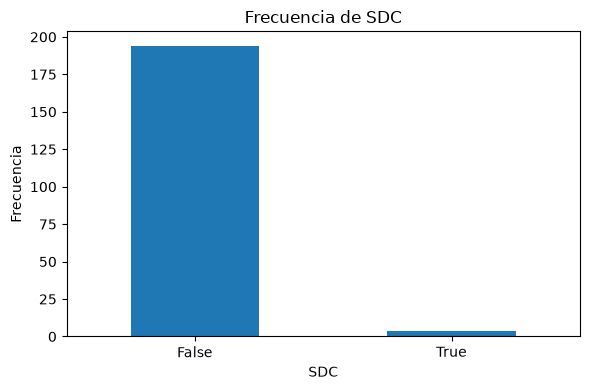

In [46]:
#Graficamos la frecuencia de SDC
Tabla_SDC.plot(
    x='SDC',
    y='Frecuencia',
    kind='bar',
    figsize=(6, 4),
    legend=False
)

plt.title('Frecuencia de SDC')
plt.xlabel('SDC')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [47]:
#VARIABLE CATEGORICA 5: VENTA

#Creamos una tabla de frecuencias para Venta
Tabla_Venta = Bitacora_de_piso['Venta'].value_counts().reset_index()

#Cambiamos los nombres de las columnas
Tabla_Venta.columns = ['Venta', 'Frecuencia']

#Calculamos el porcentaje
Tabla_Venta['Porcentaje'] = (
    Tabla_Venta['Frecuencia'] / Tabla_Venta['Frecuencia'].sum() * 100
).round(2)

#Mostramos la tabla
Tabla_Venta

,Venta,Frecuencia,Porcentaje
0,False,194,97.98
1,True,4,2.02


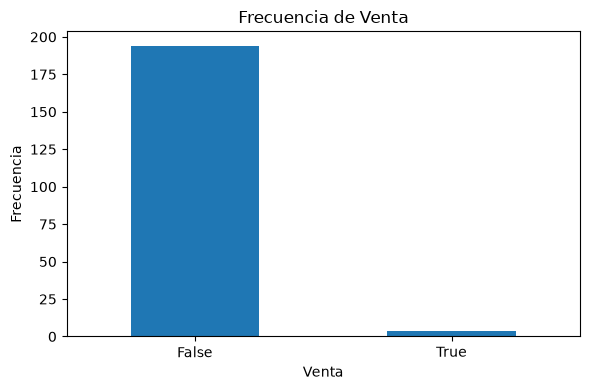

In [48]:
#Graficamos la frecuencia de la variable Venta
Tabla_Venta.plot(
    x='Venta',
    y='Frecuencia',
    kind='bar',
    figsize=(6, 4),
    legend=False
)

plt.title('Frecuencia de Venta')
plt.xlabel('Venta')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
#VARIABLE CATEGORICA 6: INTER GERENTE

#Creamos una tabla de frecuencias para Inter Gerente
Tabla_Inter_Gerente = Bitacora_de_piso['Inter Gerente'].value_counts().reset_index()

#Cambiamos los nombres de las columnas
Tabla_Inter_Gerente.columns = ['Inter Gerente', 'Frecuencia']

#Calculamos el porcentaje
Tabla_Inter_Gerente['Porcentaje'] = (
    Tabla_Inter_Gerente['Frecuencia'] / Tabla_Inter_Gerente['Frecuencia'].sum() * 100
).round(2)

#Mostramos la tabla
Tabla_Inter_Gerente

,Inter Gerente,Frecuencia,Porcentaje
0,False,167,84.34
1,True,31,15.66


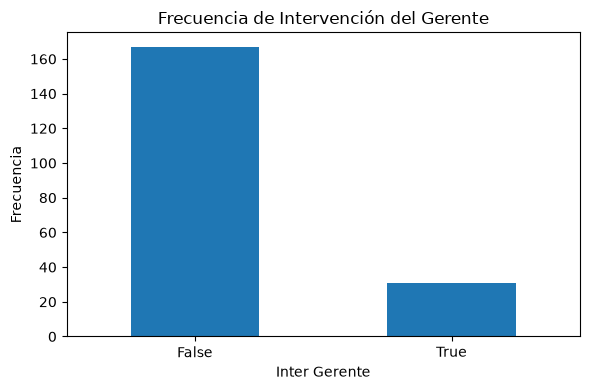

In [52]:
#Graficamos la frecuencia de Inter Gerente
Tabla_Inter_Gerente.plot(
    x='Inter Gerente',
    y='Frecuencia',
    kind='bar',
    figsize=(6, 4),
    legend=False
)

plt.title('Frecuencia de Intervención del Gerente')
plt.xlabel('Inter Gerente')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
#Convertimos la columna Fecha al formato de fecha
Bitacora_de_piso['Fecha'] = pd.to_datetime(
    Bitacora_de_piso['Fecha'],
    format='%m/%d/%Y',
    errors='coerce'
)

#Creamos una nueva característica llamada Mes
Bitacora_de_piso['Mes'] = Bitacora_de_piso['Fecha'].dt.month

#Cambiamos los números de los meses por sus nombres
meses = {
    1: 'Enero',
    2: 'Febrero',
    3: 'Marzo',
    4: 'Abril',
    5: 'Mayo',
    6: 'Junio',
    7: 'Julio',
    8: 'Agosto',
    9: 'Septiembre',
    10: 'Octubre',
    11: 'Noviembre',
    12: 'Diciembre'
}

Bitacora_de_piso['Mes'] = Bitacora_de_piso['Mes'].map(meses)

In [54]:
#VARIABLE CATEGORICA 7: MES

#Creamos una tabla de frecuencias por mes
Tabla_Mes = Bitacora_de_piso['Mes'].value_counts().reset_index()

#Cambiamos los nombres de las columnas
Tabla_Mes.columns = ['Mes', 'Frecuencia']

#Calculamos el porcentaje
Tabla_Mes['Porcentaje'] = (
    Tabla_Mes['Frecuencia'] / Tabla_Mes['Frecuencia'].sum() * 100
).round(2)

#Mostramos la tabla
Tabla_Mes

,Mes,Frecuencia,Porcentaje
0,Mayo,65,32.83
1,Junio,59,29.80
2,Abril,46,23.23
3,Julio,27,13.64
4,Agosto,1,0.51


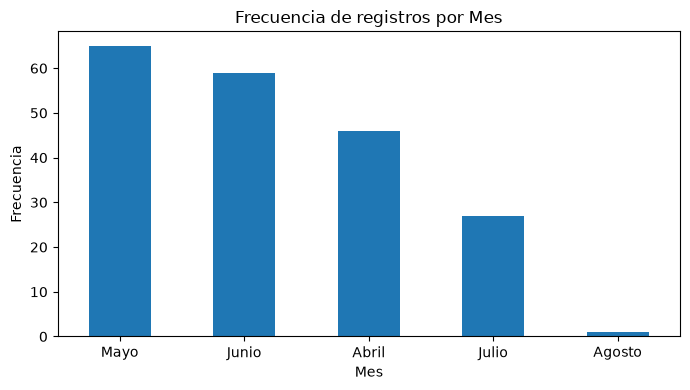

In [55]:
#Graficamos la frecuencia de registros por mes
Tabla_Mes.plot(
    x='Mes',
    y='Frecuencia',
    kind='bar',
    figsize=(7, 4),
    legend=False
)

plt.title('Frecuencia de registros por Mes')
plt.xlabel('Mes')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [60]:
#VARIABLE CATEGORICA 8: DIA DE LA SEMANA

#Creamos una nueva característica con el día de la semana
Bitacora_de_piso['Dia_semana'] = Bitacora_de_piso['Fecha'].dt.day_name()

dias = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

Bitacora_de_piso['Dia_semana'] = Bitacora_de_piso['Dia_semana'].map(dias)

In [61]:
#Creamos una tabla de frecuencias por día de la semana
Tabla_Dia = Bitacora_de_piso['Dia_semana'].value_counts().reset_index()

#Cambiamos los nombres de las columnas
Tabla_Dia.columns = ['Dia de la semana', 'Frecuencia']

#Calculamos el porcentaje
Tabla_Dia['Porcentaje'] = (
    Tabla_Dia['Frecuencia'] / Tabla_Dia['Frecuencia'].sum() * 100
).round(2)


Tabla_Dia

,Dia de la semana,Frecuencia,Porcentaje
0,Viernes,39,19.70
1,Sábado,31,15.66
2,Miércoles,29,14.65
3,Lunes,29,14.65
4,Martes,26,13.13
5,Jueves,25,12.63
6,Domingo,19,9.60


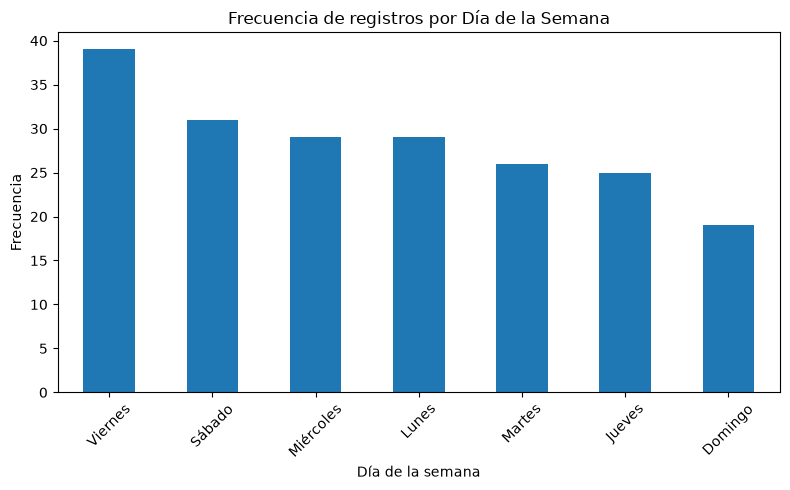

In [62]:
#Graficamos la frecuencia de registros por día de la semana
Tabla_Dia.plot(
    x='Dia de la semana',
    y='Frecuencia',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Frecuencia de registros por Día de la Semana')
plt.xlabel('Día de la semana')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
#VARIABLE CATEGORICA 9: QUINCENA

#Creamos una nueva característica llamada Quincena
Bitacora_de_piso['Quincena'] = np.where(
    Bitacora_de_piso['Fecha'].dt.day <= 15,
    'Primera quincena',
    'Segunda quincena'
)

In [64]:
#Creamos una tabla de frecuencias por quincena
Tabla_Quincena = Bitacora_de_piso['Quincena'].value_counts().reset_index()

#Cambiamos los nombres de las columnas
Tabla_Quincena.columns = ['Quincena', 'Frecuencia']

#Calculamos el porcentaje
Tabla_Quincena['Porcentaje'] = (
    Tabla_Quincena['Frecuencia'] / Tabla_Quincena['Frecuencia'].sum() * 100
).round(2)

#Mostramos la tabla
Tabla_Quincena

,Quincena,Frecuencia,Porcentaje
0,Primera quincena,103,52.02
1,Segunda quincena,95,47.98


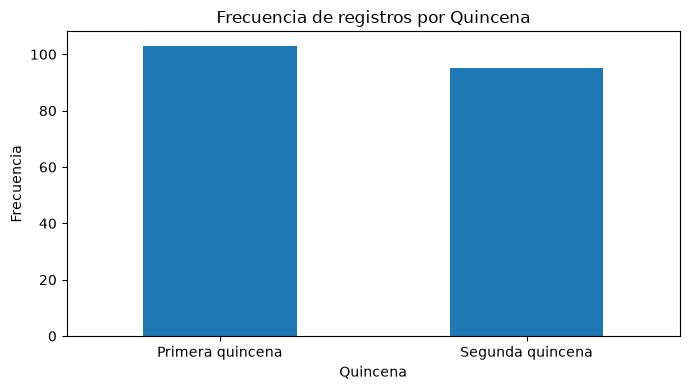

In [65]:
#Graficamos la frecuencia de registros por quincena
Tabla_Quincena.plot(
    x='Quincena',
    y='Frecuencia',
    kind='bar',
    figsize=(7, 4),
    legend=False
)

plt.title('Frecuencia de registros por Quincena')
plt.xlabel('Quincena')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [66]:
#VARIABLE CATEGORICA 10: TIPO DE DIA

#Creamos una nueva característica llamada Tipo_dia
Bitacora_de_piso['Tipo_dia'] = np.where(
    Bitacora_de_piso['Dia_semana'].isin(['Sábado', 'Domingo']),
    'Fin de semana',
    'Entre semana'
)

In [67]:
#Creamos una tabla de frecuencias por tipo de día
Tabla_Tipo_Dia = Bitacora_de_piso['Tipo_dia'].value_counts().reset_index()

#Cambiamos los nombres de las columnas
Tabla_Tipo_Dia.columns = ['Tipo de día', 'Frecuencia']

#Calculamos el porcentaje
Tabla_Tipo_Dia['Porcentaje'] = (
    Tabla_Tipo_Dia['Frecuencia'] / Tabla_Tipo_Dia['Frecuencia'].sum() * 100
).round(2)

#Mostramos la tabla
Tabla_Tipo_Dia

,Tipo de día,Frecuencia,Porcentaje
0,Entre semana,148,74.75
1,Fin de semana,50,25.25


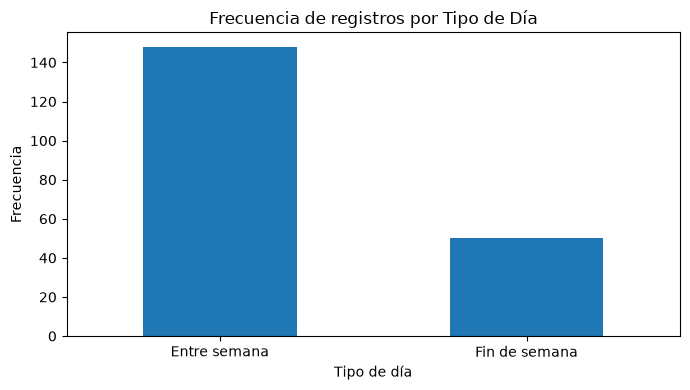

In [68]:
#Graficamos la frecuencia de registros por tipo de día
Tabla_Tipo_Dia.plot(
    x='Tipo de día',
    y='Frecuencia',
    kind='bar',
    figsize=(7, 4),
    legend=False
)

plt.title('Frecuencia de registros por Tipo de Día')
plt.xlabel('Tipo de día')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#Guardamos la base de datos depurada de Bitácora de Piso
Bitacora_de_piso.to_csv(
    'Bitacora de Piso.csv',
    index=False,
    encoding='utf-8-sig'
)

In [71]:
print("PARTE 2: CATEGORIZACION DE VARIABLES DEL ARCHIVO LEADS REALES, Aplicando la regla de los sturges")

PARTE 2: CATEGORIZACION DE VARIABLES DEL ARCHIVO LEADS REALES, Aplicando la regla de los sturges


In [76]:
#Cargamos nuevamente Leads Reales utilizando la fila correcta como encabezado
Leads_Reales = pd.read_csv(
    'Analisis GAC Full7agosto 2026(Leads Reales).csv',
    header=2
)

#Mostramos los primeros registros
Leads_Reales.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Unnamed: 12,Unnamed: 13
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN,NaN
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN,NaN
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%,NaN,NaN
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%,NaN,NaN


In [77]:
#Verificamos la información del DataFrame
Leads_Reales.info()

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   3 non-null      float64
 1   Mes                   33 non-null     str    
 2   Total                 31 non-null     str    
 3   Ilocalizable          32 non-null     str    
 4   No Contesta           31 non-null     str    
 5   D. Incorrectos        31 non-null     str    
 6   Duplicados            33 non-null     str    
 7   Efectivos             30 non-null     str    
 8   Abiertos              32 non-null     str    
 9   Ventas                30 non-null     str    
 10  Conversion            34 non-null     str    
 11  Efectividad de Leads  30 non-null     str    
 12  Unnamed: 12           2 non-null      float64
 13  Unnamed: 13           0 non-null      float64
dtypes: float64(3), str(11)
memory usage: 4.9 KB


In [78]:
#Limpiamos los nombres de las columnas
Leads_Reales.columns = Leads_Reales.columns.str.strip()

#Eliminamos las columnas Unnamed que no necesitamos
Leads_Reales = Leads_Reales.loc[
    :, ~Leads_Reales.columns.str.startswith('Unnamed')
]

#Mostramos las columnas
Leads_Reales.columns

Index(['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion',
       'Efectividad de Leads'],
      dtype='str')

In [79]:
#Completamos el año en los registros que aparecen debajo de cada año
Leads_Reales['Año'] = Leads_Reales['Año'].ffill()

In [80]:
#Definimos las variables que serán categorizadas con la regla de Sturges
variables_sturges = [
    'Total',
    'Ilocalizable',
    'No Contesta',
    'D. Incorrectos',
    'Duplicados',
    'Efectivos',
    'Abiertos',
    'Ventas',
    'Conversion',
    'Efectividad de Leads'
]

#Convertimos las variables a formato numérico
for columna in variables_sturges:
    Leads_Reales[columna] = (
        Leads_Reales[columna]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.strip()
    )

    Leads_Reales[columna] = pd.to_numeric(
        Leads_Reales[columna],
        errors='coerce'
    )

In [81]:
#Eliminamos filas que no contienen los datos necesarios para el análisis
Leads_Reales = Leads_Reales.dropna(
    subset=['Mes'] + variables_sturges
)

#Reiniciamos los índices
Leads_Reales = Leads_Reales.reset_index(drop=True)

#Verificamos nuevamente la información
Leads_Reales.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   29 non-null     float64
 1   Mes                   29 non-null     str    
 2   Total                 29 non-null     float64
 3   Ilocalizable          29 non-null     float64
 4   No Contesta           29 non-null     float64
 5   D. Incorrectos        29 non-null     float64
 6   Duplicados            29 non-null     float64
 7   Efectivos             29 non-null     float64
 8   Abiertos              29 non-null     float64
 9   Ventas                29 non-null     float64
 10  Conversion            29 non-null     float64
 11  Efectividad de Leads  29 non-null     float64
dtypes: float64(11), str(1)
memory usage: 2.8 KB


In [82]:
#VARIABLE 1 CON REGLA DE STURGES: TOTAL

#Calculamos el numero de datos
n = Leads_Reales['Total'].count()

#Calculamos el valor maximo y minimo
Max = Leads_Reales['Total'].max()
Min = Leads_Reales['Total'].min()

#Calculamos el rango
R = Max - Min

#Aplicamos la regla de Sturges
ni = 1 + 3.32 * np.log10(n)

#Redondeamos hacia arriba el numero de intervalos
k = int(np.ceil(ni))

#Calculamos la amplitud del intervalo
i = R / k

print('Numero de datos:', n)
print('Valor maximo:', Max)
print('Valor minimo:', Min)
print('Rango:', R)
print('Sturges:', ni)
print('Numero de intervalos:', k)
print('Amplitud:', i)

Numero de datos: 29
Valor maximo: 1973.0
Valor minimo: 178.0
Rango: 1795.0
Sturges: 5.855161353024534
Numero de intervalos: 6
Amplitud: 299.1666666666667


In [83]:
#Creamos los intervalos para la variable Total
intervalos_Total = np.linspace(Min, Max, k + 1)

#Creamos los nombres de las categorias
categorias_Total = [
    'Categoria 1',
    'Categoria 2',
    'Categoria 3',
    'Categoria 4',
    'Categoria 5',
    'Categoria 6'
]

#Mostramos los intervalos
intervalos_Total

array([ 178.        ,  477.16666667,  776.33333333, 1075.5       ,
       1374.66666667, 1673.83333333, 1973.        ])

In [84]:
#Categorizamos la variable Total
Leads_Reales['Total_Categoria'] = pd.cut(
    Leads_Reales['Total'],
    bins=intervalos_Total,
    labels=categorias_Total,
    include_lowest=True
)

#Mostramos los primeros registros
Leads_Reales[['Total', 'Total_Categoria']].head()

,Total,Total_Categoria
0,543.0,Categoria 2
1,178.0,Categoria 1
2,416.0,Categoria 1
3,422.0,Categoria 1
4,967.0,Categoria 3


In [85]:
#Creamos la tabla de frecuencias de las categorias de Total
Tabla_Total = Leads_Reales['Total_Categoria'].value_counts().sort_index().reset_index()

#Cambiamos los nombres de las columnas
Tabla_Total.columns = ['Categoria', 'Frecuencia']

#Mostramos la tabla
Tabla_Total

,Categoria,Frecuencia
0,Categoria 1,3
1,Categoria 2,2
2,Categoria 3,7
3,Categoria 4,9
4,Categoria 5,6
5,Categoria 6,2


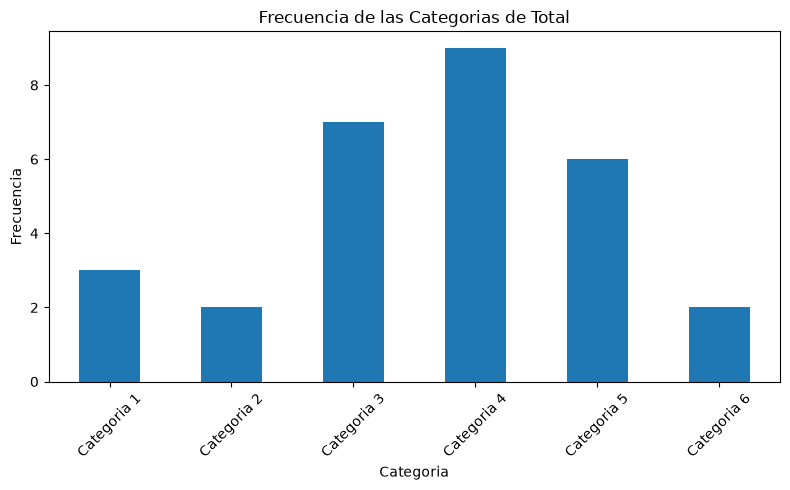

In [86]:
#Graficamos las frecuencias de las categorias de Total
Tabla_Total.plot(
    x='Categoria',
    y='Frecuencia',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Frecuencia de las Categorias de Total')
plt.xlabel('Categoria')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [87]:
#VARIABLE 2 CON REGLA DE STURGES: ILOCALIZABLE

#Calculamos el numero de datos
n = Leads_Reales['Ilocalizable'].count()

#Calculamos el valor maximo y minimo
Max = Leads_Reales['Ilocalizable'].max()
Min = Leads_Reales['Ilocalizable'].min()

#Calculamos el rango
R = Max - Min

#Aplicamos la regla de Sturges
ni = 1 + 3.32 * np.log10(n)

#Redondeamos hacia arriba el numero de intervalos
k = int(np.ceil(ni))

#Calculamos la amplitud del intervalo
i = R / k

print('Numero de datos:', n)
print('Valor maximo:', Max)
print('Valor minimo:', Min)
print('Rango:', R)
print('Sturges:', ni)
print('Numero de intervalos:', k)
print('Amplitud:', i)

Numero de datos: 29
Valor maximo: 514.0
Valor minimo: 5.0
Rango: 509.0
Sturges: 5.855161353024534
Numero de intervalos: 6
Amplitud: 84.83333333333333


In [88]:
#Creamos los intervalos para la variable Ilocalizable
intervalos_Ilocalizable = np.linspace(Min, Max, k + 1)

#Creamos los nombres de las categorias
categorias_Ilocalizable = [
    'Categoria 1',
    'Categoria 2',
    'Categoria 3',
    'Categoria 4',
    'Categoria 5',
    'Categoria 6'
]

#Mostramos los intervalos
intervalos_Ilocalizable

array([  5.        ,  89.83333333, 174.66666667, 259.5       ,
       344.33333333, 429.16666667, 514.        ])

In [89]:
#Categorizamos la variable Ilocalizable
Leads_Reales['Ilocalizable_Categoria'] = pd.cut(
    Leads_Reales['Ilocalizable'],
    bins=intervalos_Ilocalizable,
    labels=categorias_Ilocalizable,
    include_lowest=True
)

#Mostramos los primeros registros
Leads_Reales[['Ilocalizable', 'Ilocalizable_Categoria']].head()

,Ilocalizable,Ilocalizable_Categoria
0,108.0,Categoria 2
1,37.0,Categoria 1
2,79.0,Categoria 1
3,33.0,Categoria 1
4,140.0,Categoria 2


In [90]:
#Creamos la tabla de frecuencias de las categorias de Ilocalizable
Tabla_Ilocalizable = (
    Leads_Reales['Ilocalizable_Categoria']
    .value_counts()
    .sort_index()
    .reset_index()
)

#Cambiamos los nombres de las columnas
Tabla_Ilocalizable.columns = ['Categoria', 'Frecuencia']

#Mostramos la tabla
Tabla_Ilocalizable

,Categoria,Frecuencia
0,Categoria 1,13
1,Categoria 2,10
2,Categoria 3,2
3,Categoria 4,0
4,Categoria 5,1
5,Categoria 6,3


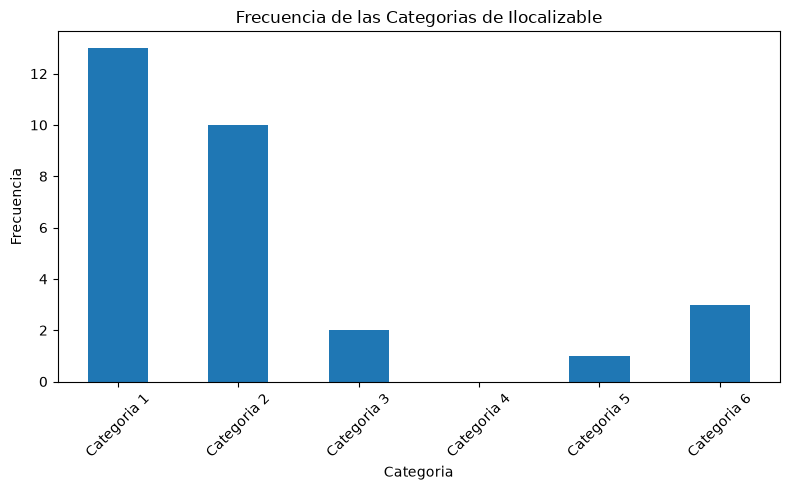

In [91]:
#Graficamos las frecuencias de las categorias de Ilocalizable
Tabla_Ilocalizable.plot(
    x='Categoria',
    y='Frecuencia',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Frecuencia de las Categorias de Ilocalizable')
plt.xlabel('Categoria')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [92]:
#VARIABLE 3 CON REGLA DE STURGES: NO CONTESTA

#Calculamos el numero de datos
n = Leads_Reales['No Contesta'].count()

#Calculamos el valor maximo y minimo
Max = Leads_Reales['No Contesta'].max()
Min = Leads_Reales['No Contesta'].min()

#Calculamos el rango
R = Max - Min

#Aplicamos la regla de Sturges
ni = 1 + 3.32 * np.log10(n)

#Redondeamos hacia arriba el numero de intervalos
k = int(np.ceil(ni))

#Calculamos la amplitud del intervalo
i = R / k

print('Numero de datos:', n)
print('Valor maximo:', Max)
print('Valor minimo:', Min)
print('Rango:', R)
print('Sturges:', ni)
print('Numero de intervalos:', k)
print('Amplitud:', i)

Numero de datos: 29
Valor maximo: 606.0
Valor minimo: 13.0
Rango: 593.0
Sturges: 5.855161353024534
Numero de intervalos: 6
Amplitud: 98.83333333333333


In [93]:
#Creamos los intervalos para la variable No Contesta
intervalos_No_Contesta = np.linspace(Min, Max, k + 1)

#Creamos los nombres de las categorias
categorias_No_Contesta = [
    'Categoria 1',
    'Categoria 2',
    'Categoria 3',
    'Categoria 4',
    'Categoria 5',
    'Categoria 6'
]

#Mostramos los intervalos
intervalos_No_Contesta

array([ 13.        , 111.83333333, 210.66666667, 309.5       ,
       408.33333333, 507.16666667, 606.        ])

In [94]:
#Categorizamos la variable No Contesta
Leads_Reales['No_Contesta_Categoria'] = pd.cut(
    Leads_Reales['No Contesta'],
    bins=intervalos_No_Contesta,
    labels=categorias_No_Contesta,
    include_lowest=True
)

#Mostramos los primeros registros
Leads_Reales[['No Contesta', 'No_Contesta_Categoria']].head()

,No Contesta,No_Contesta_Categoria
0,33.0,Categoria 1
1,13.0,Categoria 1
2,46.0,Categoria 1
3,100.0,Categoria 1
4,173.0,Categoria 2


In [95]:
#Creamos la tabla de frecuencias de las categorias de No Contesta
Tabla_No_Contesta = (
    Leads_Reales['No_Contesta_Categoria']
    .value_counts()
    .sort_index()
    .reset_index()
)

#Cambiamos los nombres de las columnas
Tabla_No_Contesta.columns = ['Categoria', 'Frecuencia']

#Mostramos la tabla
Tabla_No_Contesta

,Categoria,Frecuencia
0,Categoria 1,9
1,Categoria 2,8
2,Categoria 3,5
3,Categoria 4,4
4,Categoria 5,1
5,Categoria 6,2


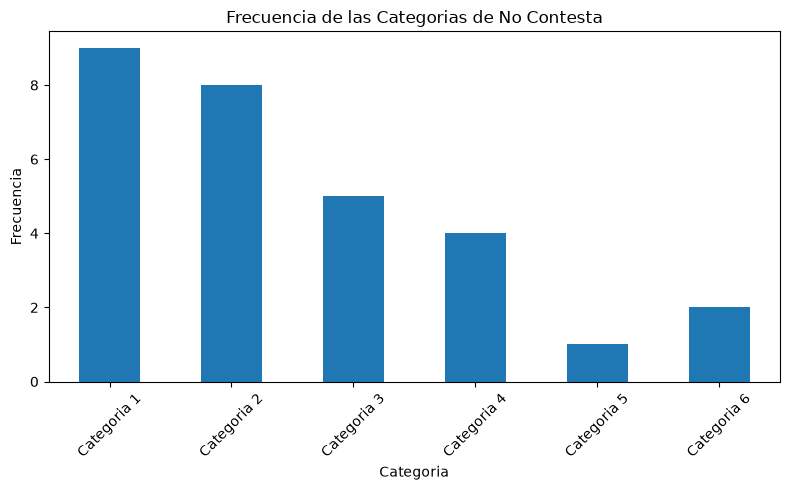

In [96]:
#Graficamos las frecuencias de las categorias de No Contesta
Tabla_No_Contesta.plot(
    x='Categoria',
    y='Frecuencia',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Frecuencia de las Categorias de No Contesta')
plt.xlabel('Categoria')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [97]:
#VARIABLE 4 CON REGLA DE STURGES: D. INCORRECTOS

#Calculamos el numero de datos
n = Leads_Reales['D. Incorrectos'].count()

#Calculamos el valor maximo y minimo
Max = Leads_Reales['D. Incorrectos'].max()
Min = Leads_Reales['D. Incorrectos'].min()

#Calculamos el rango
R = Max - Min

#Aplicamos la regla de Sturges
ni = 1 + 3.32 * np.log10(n)

#Redondeamos hacia arriba el numero de intervalos
k = int(np.ceil(ni))

#Calculamos la amplitud del intervalo
i = R / k

print('Numero de datos:', n)
print('Valor maximo:', Max)
print('Valor minimo:', Min)
print('Rango:', R)
print('Sturges:', ni)
print('Numero de intervalos:', k)
print('Amplitud:', i)

Numero de datos: 29
Valor maximo: 62.0
Valor minimo: 0.0
Rango: 62.0
Sturges: 5.855161353024534
Numero de intervalos: 6
Amplitud: 10.333333333333334


In [98]:
#Creamos los intervalos para la variable D. Incorrectos
intervalos_D_Incorrectos = np.linspace(Min, Max, k + 1)

#Creamos los nombres de las categorias
categorias_D_Incorrectos = [
    'Categoria 1',
    'Categoria 2',
    'Categoria 3',
    'Categoria 4',
    'Categoria 5',
    'Categoria 6'
]

#Mostramos los intervalos
intervalos_D_Incorrectos

array([ 0.        , 10.33333333, 20.66666667, 31.        , 41.33333333,
       51.66666667, 62.        ])

In [99]:
#Categorizamos la variable D. Incorrectos
Leads_Reales['D_Incorrectos_Categoria'] = pd.cut(
    Leads_Reales['D. Incorrectos'],
    bins=intervalos_D_Incorrectos,
    labels=categorias_D_Incorrectos,
    include_lowest=True
)

#Mostramos los primeros registros
Leads_Reales[['D. Incorrectos', 'D_Incorrectos_Categoria']].head()

,D. Incorrectos,D_Incorrectos_Categoria
0,0.0,Categoria 1
1,0.0,Categoria 1
2,3.0,Categoria 1
3,17.0,Categoria 2
4,31.0,Categoria 3


In [100]:
#Creamos la tabla de frecuencias de las categorias de D. Incorrectos
Tabla_D_Incorrectos = (
    Leads_Reales['D_Incorrectos_Categoria']
    .value_counts()
    .sort_index()
    .reset_index()
)

#Cambiamos los nombres de las columnas
Tabla_D_Incorrectos.columns = ['Categoria', 'Frecuencia']

#Mostramos la tabla
Tabla_D_Incorrectos

,Categoria,Frecuencia
0,Categoria 1,13
1,Categoria 2,7
2,Categoria 3,2
3,Categoria 4,2
4,Categoria 5,2
5,Categoria 6,3


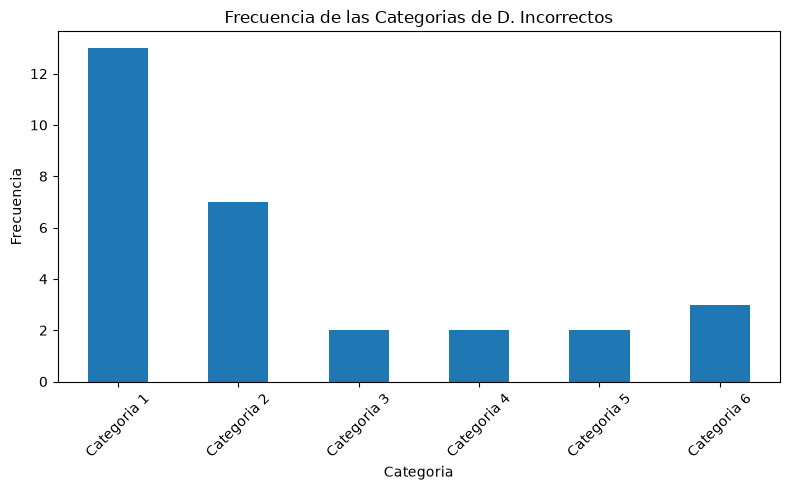

In [101]:
#Graficamos las frecuencias de las categorias de D. Incorrectos
Tabla_D_Incorrectos.plot(
    x='Categoria',
    y='Frecuencia',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Frecuencia de las Categorias de D. Incorrectos')
plt.xlabel('Categoria')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [102]:
#VARIABLE 5 CON REGLA DE STURGES: DUPLICADOS

#Calculamos el numero de datos
n = Leads_Reales['Duplicados'].count()

#Calculamos el valor maximo y minimo
Max = Leads_Reales['Duplicados'].max()
Min = Leads_Reales['Duplicados'].min()

#Calculamos el rango
R = Max - Min

#Aplicamos la regla de Sturges
ni = 1 + 3.32 * np.log10(n)

#Redondeamos hacia arriba el numero de intervalos
k = int(np.ceil(ni))

#Calculamos la amplitud del intervalo
i = R / k

print('Numero de datos:', n)
print('Valor maximo:', Max)
print('Valor minimo:', Min)
print('Rango:', R)
print('Sturges:', ni)
print('Numero de intervalos:', k)
print('Amplitud:', i)

Numero de datos: 29
Valor maximo: 136.0
Valor minimo: 0.0
Rango: 136.0
Sturges: 5.855161353024534
Numero de intervalos: 6
Amplitud: 22.666666666666668


In [103]:
#Creamos los intervalos para la variable Duplicados
intervalos_Duplicados = np.linspace(Min, Max, k + 1)

#Creamos los nombres de las categorias
categorias_Duplicados = [
    'Categoria 1',
    'Categoria 2',
    'Categoria 3',
    'Categoria 4',
    'Categoria 5',
    'Categoria 6'
]

#Mostramos los intervalos
intervalos_Duplicados

array([  0.        ,  22.66666667,  45.33333333,  68.        ,
        90.66666667, 113.33333333, 136.        ])

In [104]:
#Categorizamos la variable Duplicados
Leads_Reales['Duplicados_Categoria'] = pd.cut(
    Leads_Reales['Duplicados'],
    bins=intervalos_Duplicados,
    labels=categorias_Duplicados,
    include_lowest=True
)

#Mostramos los primeros registros
Leads_Reales[['Duplicados', 'Duplicados_Categoria']].head()

,Duplicados,Duplicados_Categoria
0,1.0,Categoria 1
1,0.0,Categoria 1
2,0.0,Categoria 1
3,0.0,Categoria 1
4,3.0,Categoria 1


In [105]:
#Creamos la tabla de frecuencias de las categorias de Duplicados
Tabla_Duplicados = (
    Leads_Reales['Duplicados_Categoria']
    .value_counts()
    .sort_index()
    .reset_index()
)

#Cambiamos los nombres de las columnas
Tabla_Duplicados.columns = ['Categoria', 'Frecuencia']

#Mostramos la tabla
Tabla_Duplicados

,Categoria,Frecuencia
0,Categoria 1,13
1,Categoria 2,7
2,Categoria 3,6
3,Categoria 4,1
4,Categoria 5,1
5,Categoria 6,1


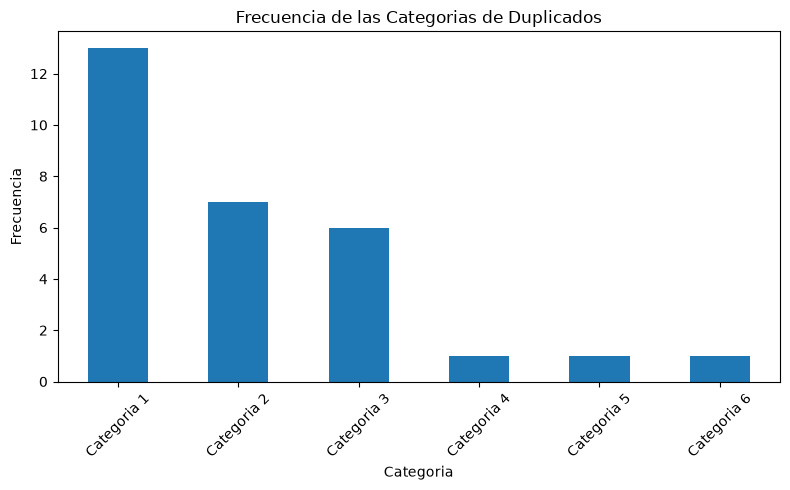

In [106]:
#Graficamos las frecuencias de las categorias de Duplicados
Tabla_Duplicados.plot(
    x='Categoria',
    y='Frecuencia',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Frecuencia de las Categorias de Duplicados')
plt.xlabel('Categoria')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [107]:
#VARIABLE 6 CON REGLA DE STURGES: EFECTIVOS

#Calculamos el numero de datos
n = Leads_Reales['Efectivos'].count()

#Calculamos el valor maximo y minimo
Max = Leads_Reales['Efectivos'].max()
Min = Leads_Reales['Efectivos'].min()

#Calculamos el rango
R = Max - Min

#Aplicamos la regla de Sturges
ni = 1 + 3.32 * np.log10(n)

#Redondeamos hacia arriba el numero de intervalos
k = int(np.ceil(ni))

#Calculamos la amplitud del intervalo
i = R / k

print('Numero de datos:', n)
print('Valor maximo:', Max)
print('Valor minimo:', Min)
print('Rango:', R)
print('Sturges:', ni)
print('Numero de intervalos:', k)
print('Amplitud:', i)

Numero de datos: 29
Valor maximo: 1040.0
Valor minimo: 128.0
Rango: 912.0
Sturges: 5.855161353024534
Numero de intervalos: 6
Amplitud: 152.0


In [108]:
#Creamos los intervalos para la variable Efectivos
intervalos_Efectivos = np.linspace(Min, Max, k + 1)

#Creamos los nombres de las categorias
categorias_Efectivos = [
    'Categoria 1',
    'Categoria 2',
    'Categoria 3',
    'Categoria 4',
    'Categoria 5',
    'Categoria 6'
]

#Mostramos los intervalos
intervalos_Efectivos

array([ 128.,  280.,  432.,  584.,  736.,  888., 1040.])

In [109]:
#Categorizamos la variable Efectivos
Leads_Reales['Efectivos_Categoria'] = pd.cut(
    Leads_Reales['Efectivos'],
    bins=intervalos_Efectivos,
    labels=categorias_Efectivos,
    include_lowest=True
)

#Mostramos los primeros registros
Leads_Reales[['Efectivos', 'Efectivos_Categoria']].head()

,Efectivos,Efectivos_Categoria
0,389.0,Categoria 2
1,128.0,Categoria 1
2,288.0,Categoria 2
3,274.0,Categoria 1
4,620.0,Categoria 4


In [110]:
#Creamos la tabla de frecuencias de las categorias de Efectivos
Tabla_Efectivos = (
    Leads_Reales['Efectivos_Categoria']
    .value_counts()
    .sort_index()
    .reset_index()
)

#Cambiamos los nombres de las columnas
Tabla_Efectivos.columns = ['Categoria', 'Frecuencia']

#Mostramos la tabla
Tabla_Efectivos

,Categoria,Frecuencia
0,Categoria 1,2
1,Categoria 2,2
2,Categoria 3,5
3,Categoria 4,13
4,Categoria 5,3
5,Categoria 6,4


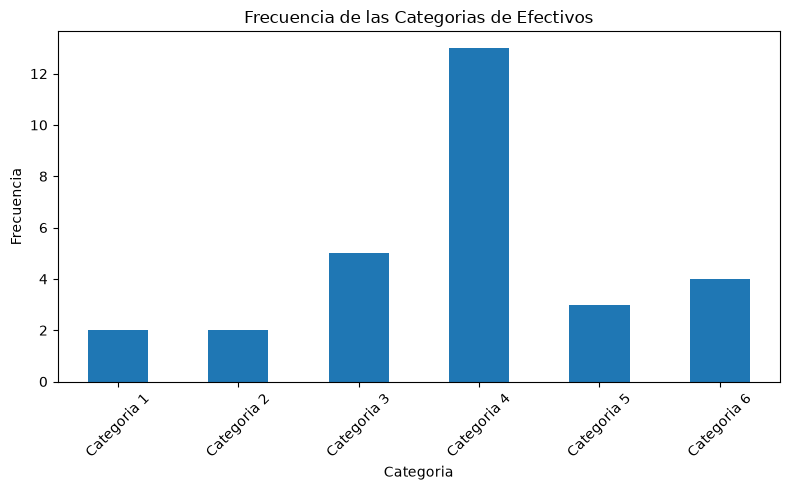

In [111]:
#Graficamos las frecuencias de las categorias de Efectivos
Tabla_Efectivos.plot(
    x='Categoria',
    y='Frecuencia',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Frecuencia de las Categorias de Efectivos')
plt.xlabel('Categoria')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [112]:
#VARIABLE 7 CON REGLA DE STURGES: ABIERTOS

#Calculamos el numero de datos
n = Leads_Reales['Abiertos'].count()

#Calculamos el valor maximo y minimo
Max = Leads_Reales['Abiertos'].max()
Min = Leads_Reales['Abiertos'].min()

#Calculamos el rango
R = Max - Min

#Aplicamos la regla de Sturges
ni = 1 + 3.32 * np.log10(n)

#Redondeamos hacia arriba el numero de intervalos
k = int(np.ceil(ni))

#Calculamos la amplitud del intervalo
i = R / k

print('Numero de datos:', n)
print('Valor maximo:', Max)
print('Valor minimo:', Min)
print('Rango:', R)
print('Sturges:', ni)
print('Numero de intervalos:', k)
print('Amplitud:', i)

Numero de datos: 29
Valor maximo: 823.0
Valor minimo: 1.0
Rango: 822.0
Sturges: 5.855161353024534
Numero de intervalos: 6
Amplitud: 137.0


In [113]:
#Creamos los intervalos para la variable Abiertos
intervalos_Abiertos = np.linspace(Min, Max, k + 1)

#Creamos los nombres de las categorias
categorias_Abiertos = [
    'Categoria 1',
    'Categoria 2',
    'Categoria 3',
    'Categoria 4',
    'Categoria 5',
    'Categoria 6'
]

#Mostramos los intervalos
intervalos_Abiertos

array([  1., 138., 275., 412., 549., 686., 823.])

In [114]:
#Categorizamos la variable Abiertos
Leads_Reales['Abiertos_Categoria'] = pd.cut(
    Leads_Reales['Abiertos'],
    bins=intervalos_Abiertos,
    labels=categorias_Abiertos,
    include_lowest=True
)

#Mostramos los primeros registros
Leads_Reales[['Abiertos', 'Abiertos_Categoria']].head()

,Abiertos,Abiertos_Categoria
0,1.0,Categoria 1
1,1.0,Categoria 1
2,1.0,Categoria 1
3,5.0,Categoria 1
4,17.0,Categoria 1


In [115]:
#Creamos la tabla de frecuencias de las categorias de Abiertos
Tabla_Abiertos = (
    Leads_Reales['Abiertos_Categoria']
    .value_counts()
    .sort_index()
    .reset_index()
)

#Cambiamos los nombres de las columnas
Tabla_Abiertos.columns = ['Categoria', 'Frecuencia']

#Mostramos la tabla
Tabla_Abiertos

,Categoria,Frecuencia
0,Categoria 1,12
1,Categoria 2,5
2,Categoria 3,5
3,Categoria 4,3
4,Categoria 5,2
5,Categoria 6,2


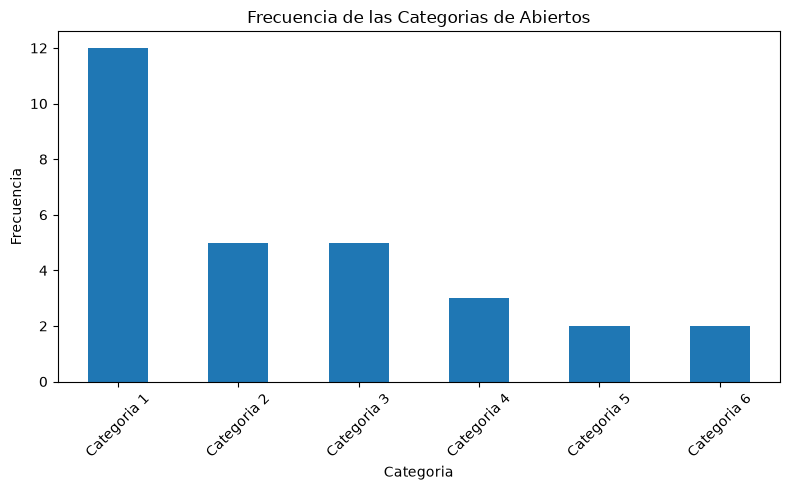

In [116]:
#Graficamos las frecuencias de las categorias de Abiertos
Tabla_Abiertos.plot(
    x='Categoria',
    y='Frecuencia',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Frecuencia de las Categorias de Abiertos')
plt.xlabel('Categoria')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [117]:
#VARIABLE 8 CON REGLA DE STURGES: VENTAS

#Calculamos el numero de datos
n = Leads_Reales['Ventas'].count()

#Calculamos el valor maximo y minimo
Max = Leads_Reales['Ventas'].max()
Min = Leads_Reales['Ventas'].min()

#Calculamos el rango
R = Max - Min

#Aplicamos la regla de Sturges
ni = 1 + 3.32 * np.log10(n)

#Redondeamos hacia arriba el numero de intervalos
k = int(np.ceil(ni))

#Calculamos la amplitud del intervalo
i = R / k

print('Numero de datos:', n)
print('Valor maximo:', Max)
print('Valor minimo:', Min)
print('Rango:', R)
print('Sturges:', ni)
print('Numero de intervalos:', k)
print('Amplitud:', i)

Numero de datos: 29
Valor maximo: 41.0
Valor minimo: 6.0
Rango: 35.0
Sturges: 5.855161353024534
Numero de intervalos: 6
Amplitud: 5.833333333333333


In [118]:
#Creamos los intervalos para la variable Ventas
intervalos_Ventas = np.linspace(Min, Max, k + 1)

#Creamos los nombres de las categorias
categorias_Ventas = [
    'Categoria 1',
    'Categoria 2',
    'Categoria 3',
    'Categoria 4',
    'Categoria 5',
    'Categoria 6'
]

#Mostramos los intervalos
intervalos_Ventas

array([ 6.        , 11.83333333, 17.66666667, 23.5       , 29.33333333,
       35.16666667, 41.        ])

In [119]:
#Categorizamos la variable Ventas
Leads_Reales['Ventas_Categoria'] = pd.cut(
    Leads_Reales['Ventas'],
    bins=intervalos_Ventas,
    labels=categorias_Ventas,
    include_lowest=True
)

#Mostramos los primeros registros
Leads_Reales[['Ventas', 'Ventas_Categoria']].head()

,Ventas,Ventas_Categoria
0,12.0,Categoria 2
1,7.0,Categoria 1
2,8.0,Categoria 1
3,13.0,Categoria 2
4,6.0,Categoria 1


In [120]:
#Creamos la tabla de frecuencias de las categorias de Ventas
Tabla_Ventas = (
    Leads_Reales['Ventas_Categoria']
    .value_counts()
    .sort_index()
    .reset_index()
)

#Cambiamos los nombres de las columnas
Tabla_Ventas.columns = ['Categoria', 'Frecuencia']

#Mostramos la tabla
Tabla_Ventas

,Categoria,Frecuencia
0,Categoria 1,3
1,Categoria 2,4
2,Categoria 3,4
3,Categoria 4,3
4,Categoria 5,7
5,Categoria 6,8


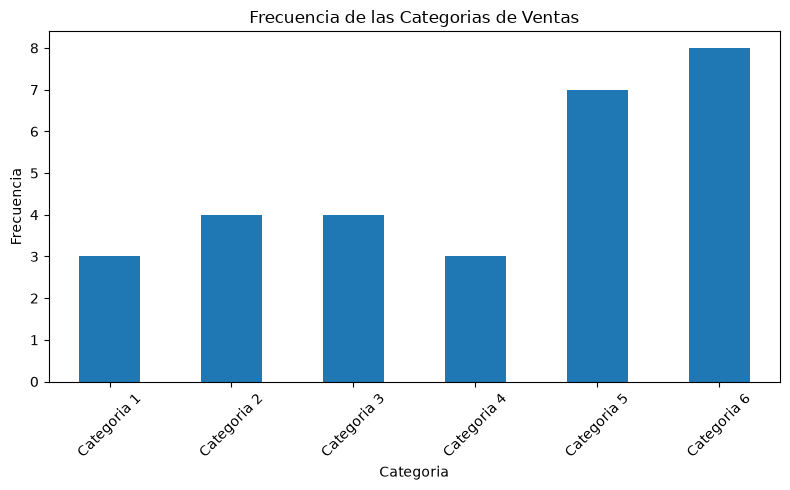

In [121]:
#Graficamos las frecuencias de las categorias de Ventas
Tabla_Ventas.plot(
    x='Categoria',
    y='Frecuencia',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Frecuencia de las Categorias de Ventas')
plt.xlabel('Categoria')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [122]:
#VARIABLE 9 CON REGLA DE STURGES: CONVERSION

#Calculamos el numero de datos
n = Leads_Reales['Conversion'].count()

#Calculamos el valor maximo y minimo
Max = Leads_Reales['Conversion'].max()
Min = Leads_Reales['Conversion'].min()

#Calculamos el rango
R = Max - Min

#Aplicamos la regla de Sturges
ni = 1 + 3.32 * np.log10(n)

#Redondeamos hacia arriba el numero de intervalos
k = int(np.ceil(ni))

#Calculamos la amplitud del intervalo
i = R / k

print('Numero de datos:', n)
print('Valor maximo:', Max)
print('Valor minimo:', Min)
print('Rango:', R)
print('Sturges:', ni)
print('Numero de intervalos:', k)
print('Amplitud:', i)

Numero de datos: 29
Valor maximo: 5.9
Valor minimo: 1.0
Rango: 4.9
Sturges: 5.855161353024534
Numero de intervalos: 6
Amplitud: 0.8166666666666668


In [123]:
#Creamos los intervalos para la variable Conversion
intervalos_Conversion = np.linspace(Min, Max, k + 1)

#Creamos los nombres de las categorias
categorias_Conversion = [
    'Categoria 1',
    'Categoria 2',
    'Categoria 3',
    'Categoria 4',
    'Categoria 5',
    'Categoria 6'
]

#Mostramos los intervalos
intervalos_Conversion

array([1.        , 1.81666667, 2.63333333, 3.45      , 4.26666667,
       5.08333333, 5.9       ])

In [124]:
#Categorizamos la variable Conversion
Leads_Reales['Conversion_Categoria'] = pd.cut(
    Leads_Reales['Conversion'],
    bins=intervalos_Conversion,
    labels=categorias_Conversion,
    include_lowest=True
)

#Mostramos los primeros registros
Leads_Reales[['Conversion', 'Conversion_Categoria']].head()

,Conversion,Conversion_Categoria
0,3.1,Categoria 3
1,5.5,Categoria 6
2,2.8,Categoria 3
3,4.7,Categoria 5
4,1.0,Categoria 1


In [125]:
#Creamos la tabla de frecuencias de las categorias de Conversion
Tabla_Conversion = (
    Leads_Reales['Conversion_Categoria']
    .value_counts()
    .sort_index()
    .reset_index()
)

#Cambiamos los nombres de las columnas
Tabla_Conversion.columns = ['Categoria', 'Frecuencia']

#Mostramos la tabla
Tabla_Conversion

,Categoria,Frecuencia
0,Categoria 1,1
1,Categoria 2,1
2,Categoria 3,7
3,Categoria 4,8
4,Categoria 5,4
5,Categoria 6,8


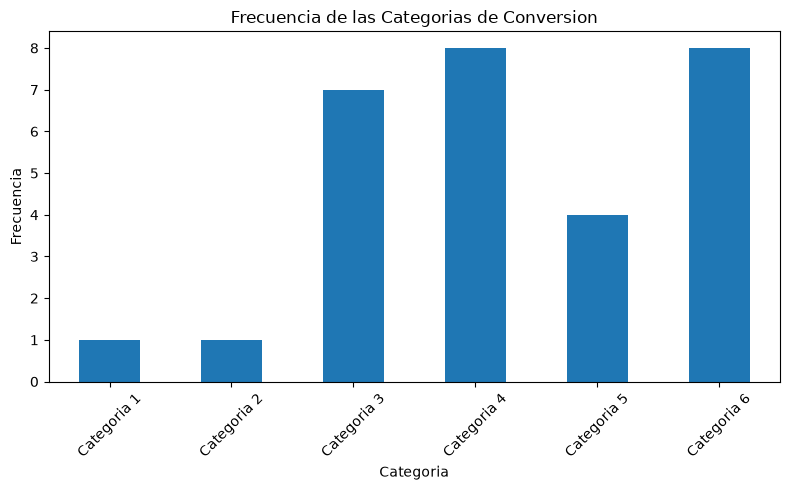

In [126]:
#Graficamos las frecuencias de las categorias de Conversion
Tabla_Conversion.plot(
    x='Categoria',
    y='Frecuencia',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Frecuencia de las Categorias de Conversion')
plt.xlabel('Categoria')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [127]:
#VARIABLE 10 CON REGLA DE STURGES: EFECTIVIDAD DE LEADS

#Calculamos el numero de datos
n = Leads_Reales['Efectividad de Leads'].count()

#Calculamos el valor maximo y minimo
Max = Leads_Reales['Efectividad de Leads'].max()
Min = Leads_Reales['Efectividad de Leads'].min()

#Calculamos el rango
R = Max - Min

#Aplicamos la regla de Sturges
ni = 1 + 3.32 * np.log10(n)

#Redondeamos hacia arriba el numero de intervalos
k = int(np.ceil(ni))

#Calculamos la amplitud del intervalo
i = R / k

print('Numero de datos:', n)
print('Valor maximo:', Max)
print('Valor minimo:', Min)
print('Rango:', R)
print('Sturges:', ni)
print('Numero de intervalos:', k)
print('Amplitud:', i)

Numero de datos: 29
Valor maximo: 83.0
Valor minimo: 39.0
Rango: 44.0
Sturges: 5.855161353024534
Numero de intervalos: 6
Amplitud: 7.333333333333333


In [128]:
#Creamos los intervalos para la variable Efectividad de Leads
intervalos_Efectividad = np.linspace(Min, Max, k + 1)

#Creamos los nombres de las categorias
categorias_Efectividad = [
    'Categoria 1',
    'Categoria 2',
    'Categoria 3',
    'Categoria 4',
    'Categoria 5',
    'Categoria 6'
]

#Mostramos los intervalos
intervalos_Efectividad

array([39.        , 46.33333333, 53.66666667, 61.        , 68.33333333,
       75.66666667, 83.        ])

In [129]:
#Categorizamos la variable Efectividad de Leads
Leads_Reales['Efectividad_Categoria'] = pd.cut(
    Leads_Reales['Efectividad de Leads'],
    bins=intervalos_Efectividad,
    labels=categorias_Efectividad,
    include_lowest=True
)

#Mostramos los primeros registros
Leads_Reales[['Efectividad de Leads', 'Efectividad_Categoria']].head()

,Efectividad de Leads,Efectividad_Categoria
0,72.0,Categoria 5
1,72.0,Categoria 5
2,69.0,Categoria 5
3,65.0,Categoria 4
4,64.0,Categoria 4


In [130]:
#Creamos la tabla de frecuencias de las categorias de Efectividad de Leads
Tabla_Efectividad = (
    Leads_Reales['Efectividad_Categoria']
    .value_counts()
    .sort_index()
    .reset_index()
)

#Cambiamos los nombres de las columnas
Tabla_Efectividad.columns = ['Categoria', 'Frecuencia']

#Mostramos la tabla
Tabla_Efectividad

,Categoria,Frecuencia
0,Categoria 1,3
1,Categoria 2,5
2,Categoria 3,5
3,Categoria 4,6
4,Categoria 5,7
5,Categoria 6,3


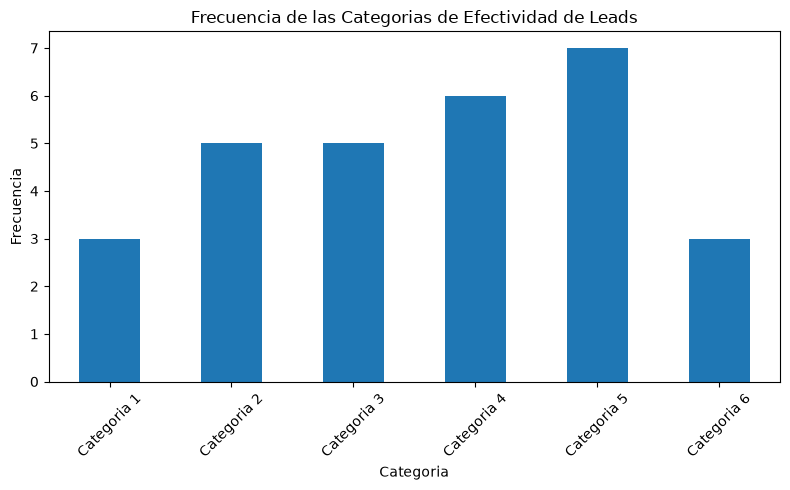

In [131]:
#Graficamos las frecuencias de las categorias de Efectividad de Leads
Tabla_Efectividad.plot(
    x='Categoria',
    y='Frecuencia',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Frecuencia de las Categorias de Efectividad de Leads')
plt.xlabel('Categoria')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [132]:
#VARIABLE 10 CON REGLA DE STURGES: EFECTIVIDAD DE LEADS

#Calculamos el numero de datos
n = Leads_Reales['Efectividad de Leads'].count()

#Calculamos el valor maximo y minimo
Max = Leads_Reales['Efectividad de Leads'].max()
Min = Leads_Reales['Efectividad de Leads'].min()

#Calculamos el rango
R = Max - Min

#Aplicamos la regla de Sturges
ni = 1 + 3.32 * np.log10(n)

#Redondeamos hacia arriba el numero de intervalos
k = int(np.ceil(ni))

#Calculamos la amplitud del intervalo
i = R / k

print('Numero de datos:', n)
print('Valor maximo:', Max)
print('Valor minimo:', Min)
print('Rango:', R)
print('Sturges:', ni)
print('Numero de intervalos:', k)
print('Amplitud:', i)

Numero de datos: 29
Valor maximo: 83.0
Valor minimo: 39.0
Rango: 44.0
Sturges: 5.855161353024534
Numero de intervalos: 6
Amplitud: 7.333333333333333


In [133]:
#Creamos los intervalos para la variable Efectividad de Leads
intervalos_Efectividad = np.linspace(Min, Max, k + 1)

#Creamos los nombres de las categorias
categorias_Efectividad = [
    'Categoria 1',
    'Categoria 2',
    'Categoria 3',
    'Categoria 4',
    'Categoria 5',
    'Categoria 6'
]

#Mostramos los intervalos
intervalos_Efectividad

array([39.        , 46.33333333, 53.66666667, 61.        , 68.33333333,
       75.66666667, 83.        ])

In [134]:
#Categorizamos la variable Efectividad de Leads
Leads_Reales['Efectividad_Categoria'] = pd.cut(
    Leads_Reales['Efectividad de Leads'],
    bins=intervalos_Efectividad,
    labels=categorias_Efectividad,
    include_lowest=True
)

#Mostramos los primeros registros
Leads_Reales[['Efectividad de Leads', 'Efectividad_Categoria']].head()

,Efectividad de Leads,Efectividad_Categoria
0,72.0,Categoria 5
1,72.0,Categoria 5
2,69.0,Categoria 5
3,65.0,Categoria 4
4,64.0,Categoria 4


In [135]:
#Creamos la tabla de frecuencias de las categorias de Efectividad de Leads
Tabla_Efectividad = (
    Leads_Reales['Efectividad_Categoria']
    .value_counts()
    .sort_index()
    .reset_index()
)

#Cambiamos los nombres de las columnas
Tabla_Efectividad.columns = ['Categoria', 'Frecuencia']

#Mostramos la tabla
Tabla_Efectividad

,Categoria,Frecuencia
0,Categoria 1,3
1,Categoria 2,5
2,Categoria 3,5
3,Categoria 4,6
4,Categoria 5,7
5,Categoria 6,3


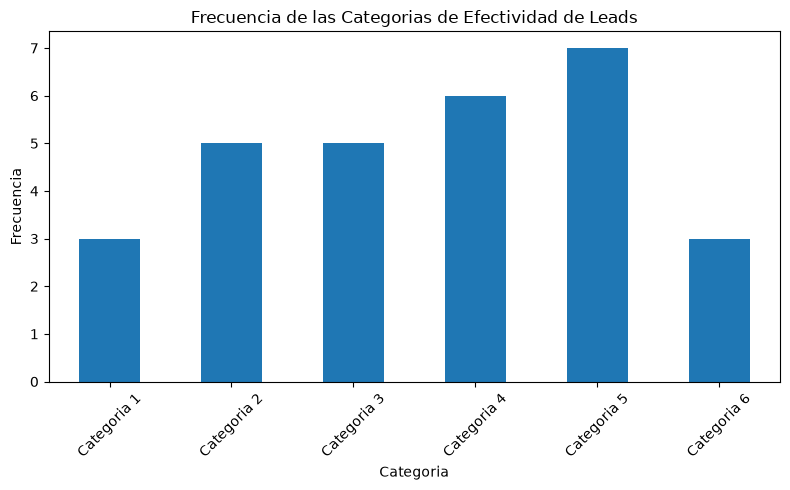

In [136]:
#Graficamos las frecuencias de las categorias de Efectividad de Leads
Tabla_Efectividad.plot(
    x='Categoria',
    y='Frecuencia',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Frecuencia de las Categorias de Efectividad de Leads')
plt.xlabel('Categoria')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()